In [1]:
import pandas as pd
import numpy as np

from keras.utils import image_dataset_from_directory
import tensorflow as tf

# Importation pour utiliser un modèle pre entrainé
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.neighbors import NearestNeighbors

from pathlib import Path

In [2]:
chemin="/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE"

dataset=image_dataset_from_directory (chemin,
                                      image_size=(224, 224),
                                      batch_size = 32,
                                      shuffle=False,
                                      color_mode='rgb')

Found 20835 files belonging to 4 classes.


2026-08-01 13:05:47.634300: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-08-01 13:05:47.634331: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-01 13:05:47.634335: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1785582347.634637  231147 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1785582347.634896  231147 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
process_ds=dataset.map(lambda x,y: (preprocess_input(x),y))

In [4]:
#Choix du device
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


On charge ici le modèle EfficientNet et on gèle toutes les couches. L'argument polling="avg" permet de transfromer chaque radiographie en vecteure de 1280 caractéristiques.

In [5]:
base_model=EfficientNetB0(weights="imagenet", include_top=False, pooling="avg")

#Gel des couches

base_model.trainable = False

base_model

<Functional name=efficientnetb0, built=True>

On passe ensuite les images dans le modèle préentraîné. On crée ainsi une matrice qui servira à la recherche de similarités.

In [6]:
embedding = base_model.predict(process_ds)

2026-08-01 13:05:58.772176: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


652/652 ━━━━━━━━━━━━━━━━━━━━ 167s 254ms/step


In [7]:
embedding.shape

(20835, 1280)

On détermine les 20 plus proches voisins de chaque image en fonction de la métrique cosine.

In [8]:
nn = NearestNeighbors(
    metric="cosine",
    n_neighbors=20
)

nn.fit(embedding)

distances, indices = nn.kneighbors(embedding)

In [9]:
distances.shape

(20835, 20)

In [10]:
indices.shape

(20835, 20)

In [11]:
distances

array([[0.0000000e+00, 6.5166473e-02, 7.2327912e-02, ..., 8.0488026e-02,
        8.1839800e-02, 8.2509220e-02],
       [1.1324883e-06, 4.7094584e-02, 4.7388256e-02, ..., 5.7395995e-02,
        5.8052838e-02, 5.8525145e-02],
       [0.0000000e+00, 5.8743179e-02, 6.0596406e-02, ..., 8.3284676e-02,
        8.3445847e-02, 8.4274352e-02],
       ...,
       [0.0000000e+00, 4.9047410e-02, 5.3206563e-02, ..., 7.2847843e-02,
        7.3002577e-02, 7.3249876e-02],
       [0.0000000e+00, 5.8148742e-02, 6.4687550e-02, ..., 8.9868367e-02,
        8.9929760e-02, 9.1709495e-02],
       [2.9802322e-07, 3.8011193e-02, 4.0655315e-02, ..., 4.9972773e-02,
        5.0054133e-02, 5.0179124e-02]], dtype=float32)

In [12]:
similarites=1-distances[:, 1:]

In [13]:
print(similarites)

[[0.9348335  0.9276721  0.9269307  ... 0.919512   0.9181602  0.9174908 ]
 [0.9529054  0.95261174 0.9511492  ... 0.942604   0.94194716 0.94147485]
 [0.9412568  0.9394036  0.9318078  ... 0.9167153  0.91655415 0.91572565]
 ...
 [0.9509526  0.94679344 0.94212    ... 0.92715216 0.9269974  0.9267501 ]
 [0.94185126 0.93531245 0.93439764 ... 0.91013163 0.91007024 0.9082905 ]
 [0.9619888  0.9593447  0.9592644  ... 0.9500272  0.94994587 0.9498209 ]]


In [14]:
img_chemin = sorted(Path(chemin).glob("*/*.png"))

In [21]:
nb_images = indices.shape[0]
print(nb_images)

for image in np.arange(nb_images):
    for voisin, similarite in zip(indices[image][1:], similarites[image][1:]):
        if similarite > 0.9:
            print("True")
            print (img_chemin[voisin])

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



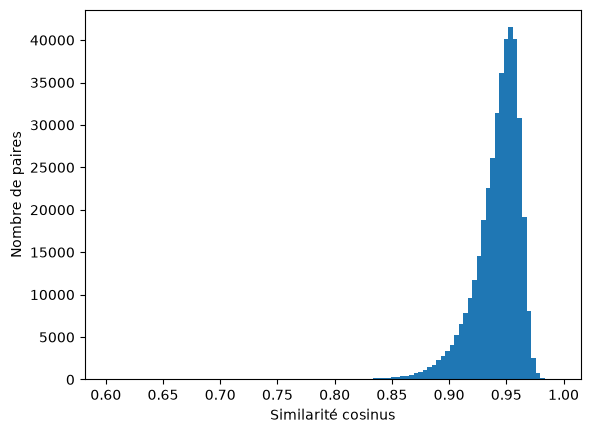

In [18]:
import matplotlib.pyplot as plt

plt.hist(similarites.flatten(), bins=100)
plt.xlabel("Similarité cosinus")
plt.ylabel("Nombre de paires")
plt.show()